---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 2"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 11. Операторний метод розрахунку перехідних процесів</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Операторний метод розрахунку перехідних процесів</li>
  <li>Закони Кірхгофа в операторній формі</li>
  <li>Властивості перетворення Лапласа</li>
  <li>Таблиця перетворень Лапласа (основні пари)</li>
  <li>Розрахунок перехідного процесу RC ланцюга операторним методом</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 11 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Операторний метод розрахунку перехідних процесів](#commutation-calculation-laplace)
    * [Закони Кірхгофа в операторній формі](#Laplace-laws)
    * [Властивості перетворення Лапласа](#Laplace-properties)
    * [Таблиця перетворень Лапласа (основні пари)](#laplace-table)
    * [Розрахунок перехідного процесу RC ланцюга операторним методом](#RC-commutation-calculation-laplace)
* [📌 Підсумок теми](#topic-summary)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
import sympy as sp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Операторний метод розрахунку перехідних процесів  <a class="anchor" id="commutation-calculation-laplace"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати сутність перетворення Лапласа
> - Застосовувати таблицю перетворень Лапласа
> - Записувати закони Кірхгофа в операторній формі
> - Розраховувати перехідні процеси операторним методом
> - Застосовувати формулу розкладу для знаходження оригіналів

</div>

### Перетворення Лапласа: основні пари

| Оригінал $f(t)$ | Зображення $F(p)$ | Назва |
|----------------|-----------------|-------|
| $1$ | $\dfrac{1}{p}$ | Одиничний стрибок |
| $t$ | $\dfrac{1}{p^2}$ | Лінійна функція |
| $e^{-at}$ | $\dfrac{1}{p+a}$ | Експонента |
| $\sin(\omega t)$ | $\dfrac{\omega}{p^2+\omega^2}$ | Синус |
| $\cos(\omega t)$ | $\dfrac{p}{p^2+\omega^2}$ | Косинус |
| $\delta(t)$ | $1$ | Дельта-функція |



### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Операторне числення розробив у 1880-х **Олівер Хевісайд** — інженер-самоучка, який також вивів **телеграфне рівняння** (розділ «Довга лінія» далі в цьому конспекті) та ввів позначення $j=\sqrt{-1}$ для розрахунків кіл змінного струму. Математики того часу критикували його метод за відсутність строгого обґрунтування — воно з'явилося лише через десятиліття, коли Т. Бромвіч показав його зв'язок саме з перетворенням Лапласа.


</div>


### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не плутайте оператор Лапласа $p = \sigma + j\omega$ із символічним методом $j\omega$ із Частини 1. Символічний метод — окремий випадок операторного при $\sigma = 0$ (чисто усталений синусоїдний режим). Оператор $p$ загальніший: дійсна частина $\sigma$ описує загасання/наростання перехідного процесу, а уявна $j\omega$ — коливальну складову. Щоб перейти від $H(p)$ до частотної характеристики $H(j\omega)$, достатньо підставити $p \to j\omega$ — але це коректно лише для **стійкого** кола в **усталеному** режимі.


</div>


Сутність **операторного методу** полягає в тому, що функції $f(x)$ дійсної змінної t, яку називають **оригіналом**, ставиться у відповідність функція $F(p)$ комплексної змінної $p = s + j \omega$, яку називають **зображенням**. В результаті цього похідні та інтеграли від оригіналів замінюються алгебраїчними функціями від відповідних зображень (диференціювання замінюється множенням на оператор р, а інтегрування - діленням на нього), що в свою чергу визначає перехід від системи **інтегро-диференціальних рівнянь до системи алгебраїчних рівнянь** щодо зображень шуканих змінних . При вирішенні цих рівнянь знаходяться зображення і далі шляхом зворотного переходу - оригінали. Найважливішим моментом при цьому в практичному плані є необхідність визначення тільки незалежних початкових умов, що істотно полегшує розрахунок перехідних процесів в ланцюгах високого порядку в порівнянні з класичним методом.

Зображення заданої функції визначається відповідно з прямим перетворенням Лапласа:

$$
F(p) = \int_{0}^{\infty}e^{-pt}f(t)dt;
$$

У скороченою записи відповідність між зображенням і оригіналом позначається, як:

$$
F(p) = f(t) \quad   або \quad  F(p) = L\{f(t)\};
$$

Слід зазначити, що якщо оригінал збільшується з ростом t, то для збіжності інтеграла (1) необхідно більш швидке спадання модуля  . Функції, з якими зустрічаються на практиці при розрахунку перехідних процесів, цій умові задовольняють. В якості прикладу в табл. 1 наведено зображення деяких характерних функцій, що часто зустрічаються при аналізі нестаціонарних режимів.

---
### Закони Кірхгофа в операторній формі  <a class="anchor" id="Laplace-laws"></a>

**Перший закон Кірхгофа**: алгебраїчна сума зображень струмів, що сходяться у вузлі, дорівнює нулю

$$
\sum_{k=1}^{n} I_{k}(p) = 0;
$$

**Другий закон Кірхгофа**: алгебраїчна сума зображень ЕРС, що діють в контурі, дорівнює алгебраїчній сумі зображень напруг на пасивних елементах цього контуру

$$
\sum_{k=1}^{m} E_{k}(p) = \sum_{k=1}^{m} v_{k}(p);
$$

### Властивості перетворення Лапласа  <a class="anchor" id="Laplace-properties"></a>

Лінійність:

$$
a_{1}f_{1}(t)+a_{2}f_{2}(t)+... \rightarrow a_{1}F_{1}(p)+a_{2}F_{2}(p)+...;
$$

Теорема інтегрування:

$$
x(t) = \int_{0}^{t}f(t)dt+x(0) \rightarrow \frac{1}{p}F(p)+\frac{1}{p}x(0);
$$

Теорема диференціювання:

$$
\frac{d}{dt}f(t) \rightarrow pF(p) - f(0_{+});
$$

$$
\frac{d^{2}}{dt^{2}}f(t) \rightarrow p^{2}F(p) - pf(0_{+}) - \frac{d}{dt}f(0_{+});
$$

$$
\frac{d^{n}}{dt^{n}}f(t) \rightarrow p^{n}F(p) - p^{n-1}f(0_{+}) - p^{n-2}\frac{d}{dt}f(0_{+})-...p\frac{d^{n-2}}{dt^{n-2}}f(0_{+}) - \frac{d^{n-1}}{dt^{n-1}}f(0_{+});
$$

Теорема запізнювання:

$$
f(t-t_{0}) \rightarrow F(p)e^{-pt};
$$


---
### Таблиця перетворень Лапласа (основні пари) <a class="anchor" id="laplace-table"></a>

| Оригінал $f(t)$, $t \geq 0$ | Зображення $F(p)$ | Примітка |
|------------------------------|------------------|----------|
| $\delta(t)$ — дельта-функція | $1$ | Імпульсна характеристика |
| $\mathbf{1}(t)$ — одиничний стрибок | $\dfrac{1}{p}$ | Ступінчате збудження |
| $e^{-at}$ | $\dfrac{1}{p+a}$ | Експоненційний спад |
| $t \cdot e^{-at}$ | $\dfrac{1}{(p+a)^2}$ | Критичний випадок RL/RC |
| $\sin(\omega t)$ | $\dfrac{\omega}{p^2+\omega^2}$ | Синусоїдне збудження |
| $\cos(\omega t)$ | $\dfrac{p}{p^2+\omega^2}$ | Косинусоїдне збудження |
| $e^{-at}\sin(\omega t)$ | $\dfrac{\omega}{(p+a)^2+\omega^2}$ | Затухаючі коливання |
| $e^{-at}\cos(\omega t)$ | $\dfrac{p+a}{(p+a)^2+\omega^2}$ | Затухаючі коливання |

**Теореми:**

| Теорема | Формула |
|---------|--------|
| Диференціювання | $\mathcal{L}\{f'(t)\} = p \cdot F(p) - f(0_+)$ |
| Інтегрування | $\mathcal{L}\left\{\int_0^t f\,d\tau\right\} = \dfrac{F(p)}{p}$ |
| Запізнення | $\mathcal{L}\{f(t-\tau)\} = e^{-p\tau} F(p)$ |
| Початкове значення | $f(0_+) = \lim_{p\to\infty} p F(p)$ |
| Кінцеве значення | $f(\infty) = \lim_{p\to 0} p F(p)$ |

#### Правила переходу від оригіналу до зображення  <a class="anchor" id="Laplace-transform-law"></a>

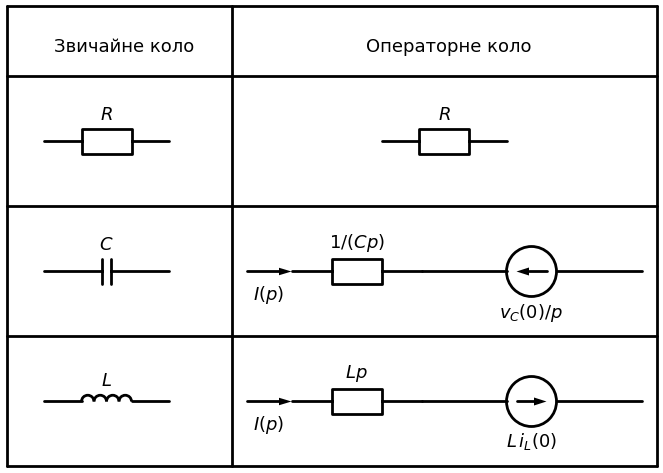

In [2]:
# Схема: елементи звичайного кола та їх операторні схеми заміщення (з урахуванням ненульових початкових умов)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=2.5) as d:
        W, H = 13, 2.6
        for y in [0, -1.4, -1.4 - H, -1.4 - 2*H, -1.4 - 3*H]:
            d.add(elm.Line().at((0, y)).right(W))
        for x in [0, 4.5, W]:
            d.add(elm.Line().at((x, 0)).down(1.4 + 3*H))
        d.add(elm.Label().at((2.25, -0.7)).label('Звичайне коло'))
        d.add(elm.Label().at((8.75, -0.7)).label('Операторне коло'))
        yc = [-1.4 - H/2 - k*H for k in range(3)]
        # R
        d.add(elm.Resistor().at((0.75, yc[0])).right().label('$R$'))
        d.add(elm.Resistor().at((7.5, yc[0])).right().label('$R$'))
        # C: 1/(Cp) послідовно з ЕРС v_C(0)/p, напрямленою назустріч струму
        d.add(elm.Capacitor().at((0.75, yc[1])).right().label('$C$'))
        d.add(elm.Arrow().at((4.8, yc[1])).right(0.9).label('$I(p)$', loc='bottom'))
        d.add(elm.Resistor().right(2.6).label('$1/(Cp)$'))
        d.add(EMF().left().at((12.7, yc[1])).to((8.3, yc[1])).label('$v_C(0)/p$', loc='bottom'))
        # L: Lp послідовно з ЕРС L·i(0), напрямленою за струмом
        d.add(elm.Inductor().at((0.75, yc[2])).right().label('$L$'))
        d.add(elm.Arrow().at((4.8, yc[2])).right(0.9).label('$I(p)$', loc='bottom'))
        d.add(elm.Resistor().right(2.6).label('$Lp$'))
        d.add(EMF().at((8.3, yc[2])).right(4.4).label('$L\\,i_L(0)$', loc='bottom'))

---

### Розрахунок перехідного процесу RC ланцюга операторним методом  <a class="anchor" id="RC-commutation-calculation-laplace"></a>

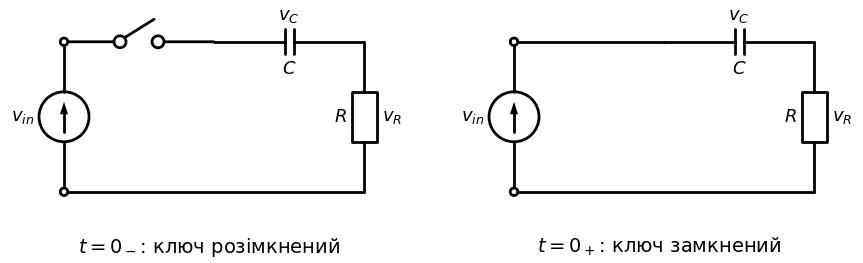

In [3]:
# Схема: RC-коло до і після комутації
if SCHEMDRAW_AVAILABLE:
    def switching_pair(element, name, value_label):
        """Коло до комутації (ключ розімкнений, t = 0−) і після неї (ключ замкнений, t = 0+)."""
        with schemdraw.Drawing(fontsize=13, unit=3) as d:
            for x0, closed, caption in [(0, False, '$t = 0_-$: ключ розімкнений'), (9, True, '$t = 0_+$: ключ замкнений')]:
                src = d.add(EMF().at((x0, 0)).up().label('$v_{in}$'))
                d.add(elm.Dot(open=True).at(src.end))
                if closed:
                    d.add(elm.Line().at(src.end).right(3))
                else:
                    d.add(elm.Switch().at(src.end).right())
                d.add(element().right().label(name).label(value_label, loc='bottom'))
                d.add(elm.Resistor().down().label('$R$', loc='top').label('$v_R$', loc='bottom'))
                d.add(elm.Line().left().tox(src.start))
                d.add(elm.Dot(open=True).at(src.start))
                d.add(elm.Label().at((x0 + 3, -1.0)).label(caption, fontsize=14))

    switching_pair(elm.Capacitor, '$v_C$', '$C$')

---

Виконаємо розрахунок для наступних параметрів схеми:

$$v_{in} = 80 [V] \quad R=40 [\Omega] \quad C = 0.1 [mF] $$

---

Запишемо операторну схему заміщення

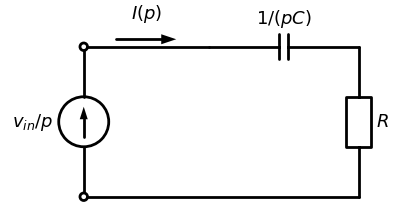

In [4]:
# Схема: операторна схема заміщення RC-кола (u_C(0) = 0)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        src = d.add(EMF().up().label('$v_{in}/p$'))
        d.add(elm.Dot(open=True).at(src.end))
        w = d.add(elm.Line().right(2.5))
        d.add(elm.CurrentLabel(top=True, length=1.2).at(w).label('$I(p)$'))
        d.add(elm.Capacitor().right().label('$1/(pC)$'))
        d.add(elm.Resistor().down().label('$R$', loc='bottom'))
        d.add(elm.Line().left().tox(src.start))
        d.add(elm.Dot(open=True).at(src.start))

Запишемо рівняння:

$$
  Z(p) = R + \cfrac{1}{pC};
$$

Приведемо до загального знаменника:

$$
  Z(p) = \cfrac{RpC+1}{pC};
$$

Визначимо струм в контурі поділивши вхідну напругу на повний опір схеми:

$$
  I(p) = (\cfrac{v_{in}}{p}) / (\cfrac{RpC+1}{pC}) = (\cfrac{v_{in}}{p}) \cdot (\cfrac{pC}{RpC+1});
$$

Скоротимo p:

$$
  I(p) =  \cfrac{v_{in}C}{RpC+1};
$$

Визначимо напругу на резисторі $R$:

$$
  v_{r}(p) = R \cdot I(p) =  R \cdot \cfrac{v_{in}C}{RpC+1};
$$

Запишемо рівняння по 2-му закону Кірхгофа:

$$
  v_{r}(p) + v_{с}(p) = \cfrac{v_{in}}{p};
$$

Тоді:

$$
   v_{с}(p) = \cfrac{v_{in}}{p} - v_{r}(p) = \cfrac{v_{in}}{p} - R \cdot \cfrac{v_{in}C}{RpC+1};
$$

Приведемо до загального знаменника:

$$
   v_{с}(p) = \cfrac{
   v_{in}(RpC+1) - pv_{in}RC
   }
   {
   p(RpC+1)
   }  
$$

Розкриємо дужки і отримаємо фінальне зображення напруги на конденсаторі $v_{с}(p)$:

$$
   v_{с}(p) = 
   \cfrac{
   v_{in}RCp+v_{in}- pv_{in}RC
   }
   {
   p(RpC+1)
   }
   =
   \cfrac{
   v_{in}
   }
   {
   p(RpC+1)
   }
   =
   \cfrac{
   F_{1}(p)
   }
   {
   F_{2}(p)
   }
$$

Для перевірки знайдемо корені знаменника і порівняємо з класичним методом:

$$
   p(RpC+1) = 0
$$

Перший корінь

$$
   p_{0} = 0
$$

Другий корінь

$$
   RpC+1 = 0
$$

Тоді $р_{1}$:

$$
  p_{1} = \cfrac{-1}{RC} = -\frac{1}{4*10^{-3}} = -250;
$$

$$
  F_{1}(p) = v_{in} = 80;\\
  F_{1}(p_{0}) = 80;\\
  F_{1}(p_{1}) = 80;
$$

$$
  F^{'}_{2}(p) =  p^2RC+p;
$$

Візьмемо похідну і підставимо отримані корені:

$$
  F_{2}(p) =  2pRC+1;
$$

$$
  F^{'}_{2}(p_{0}) = F^{'}_{2}(0) =1;
$$

$$
  F^{'}_{2}(p_{1}) = 2 \cdot -250 \cdot 40 \cdot (0.1) \cdot 10^{-3} + 1 = -1;
$$

Запишемо формулу переходу в часовій області:

$$
  v_{c}(t) = 
  \cfrac{F_{1}(p_{0})}{F^{'}_{2}(p_{0})} \cdot e^{p_{0}t} +
  \cfrac{F_{1}(p_{1})}{F^{'}_{2}(p_{1})} \cdot  e^{p_{1}t};
$$

$$
  v_{c}(t) = \cfrac{80}{1} + \cfrac{80}{-1} \cdot  e^{-250\cdot t};
$$

Розв'язок:
$$
v_{c}(t) = 80 - 80 e^{-250 \cdot t} [V];
$$

#### Перевірка операторного розрахунку за допомогою SymPy

Функція `sympy.inverse_laplace_transform` виконує зворотне перетворення Лапласа — отримуємо оригінали $i(t)$ та $u_C(t)$ і порівнюємо їх з результатом, знайденим за формулою розкладу.

In [5]:
# Перевірка: зворотне перетворення Лапласа для RC ланцюга (v_in = 80 В, R = 40 Ом, C = 0.1 мФ)
def rc_laplace_check(v_in=80, R_val=40, C_val=0.1e-3):
    t_, p_ = smp.symbols('t p', positive=True)
    I_p = (smp.Integer(v_in)/p_) / (R_val + 1/(p_*smp.nsimplify(C_val)))   # I(p) = U(p)/Z(p)
    Uc_p = I_p/(p_*smp.nsimplify(C_val))                                  # U_C(p) = I(p)/(pC)
    i_t = smp.inverse_laplace_transform(smp.simplify(I_p), p_, t_)
    uc_t = smp.inverse_laplace_transform(smp.apart(smp.simplify(Uc_p), p_), p_, t_)
    display(Markdown(rf'$I(p) = {smp.latex(smp.simplify(I_p))} \;\Rightarrow\; i(t) = {smp.latex(i_t)}$'))
    display(Markdown(rf'$U_C(p) = {smp.latex(smp.simplify(Uc_p))} \;\Rightarrow\; u_C(t) = {smp.latex(smp.expand(uc_t))}$'))
    return i_t, uc_t

rc_laplace_check();

$I(p) = \frac{2}{p + 250} \;\Rightarrow\; i(t) = 2 e^{- 250 t}$

$U_C(p) = \frac{20000}{p \left(p + 250\right)} \;\Rightarrow\; u_C(t) = 80 - 80 e^{- 250 t}$

---
### 📐 Формула розкладу і її застосування при розрахунку перехідних процесів

Ці формули дозволяють знайти оригінал $f(t)$, якщо зображення задано дробово-раціональною функцією:

$$
F(p) = \frac{F_1(p)}{F_2(p)} = \frac{a_m p^m + a_{m-1}p^{m-1} + \ldots + a_1 p + a_0}{b_n p^n + b_{n-1}p^{n-1} + \ldots + b_1 p + b_0}
$$

Формулу розкладання можна застосовувати тільки тоді, коли степінь чисельника нижчий за степінь знаменника ($m < n$). Якщо це не так, спочатку ділять чисельник на знаменник, виділяючи цілу частину, і застосовують формулу розкладання лише до правильного дробового залишку.

Характеристичне рівняння $F_2(p) = 0$ визначає корені $p_k$, кожному з яких відповідає доданок в оригіналі:

**1. Простий дійсний корінь $p_k$:**
$$
f_k(t) = \frac{F_1(p_k)}{F_2'(p_k)} \, e^{p_k t}
$$

**2. Пара простих комплексно-спряжених коренів $p_{1,2} = -\sigma \pm j\omega$:**

Обчисливши лишок при корені з додатною уявною частиною $p_1$: $\dfrac{F_1(p_1)}{F_2'(p_1)} = M e^{j\psi}$ (у показниковій формі), сума доданків від обох спряжених коренів дає **дійсну** функцію:
$$
f_{1,2}(t) = 2M\, e^{-\sigma t}\cos(\omega t + \psi)
$$

**3. Кратний корінь $p_k$ кратності 2** (тобто $F_2(p) = (p-p_k)^2 \tilde{F}_2(p)$):
$$
f_k(t) = \left(\frac{F_1(p_k)}{\tilde{F}_2(p_k)}\, t + \left[\frac{F_1(p)}{\tilde{F}_2(p)}\right]'_{p=p_k}\right) e^{p_k t}
$$
Найпростіший практичний приклад кратного кореня — **критичний режим** RLC ланцюга (розділ «Перехідні процеси 2-го порядку» нижче), де $p_{1,2} = -\alpha$ і розв'язок містить доданок вигляду $(A + Bt)e^{-\alpha t}$.

#### Приклад застосування формули розкладання

Нехай зображення струму має вигляд:
$$
I(p) = \frac{24}{p(p+2)(p+4)}
$$

Тут $F_1(p) = 24$, $F_2(p) = p(p+2)(p+4) = p^3 + 6p^2 + 8p$, звідки $F_2'(p) = 3p^2 + 12p + 8$. Характеристичне рівняння $F_2(p)=0$ дає три прості дійсні корені: $p_0 = 0$, $p_1 = -2$, $p_2 = -4$.

Обчислюємо $F_2'(p)$ у кожному корені:
$$
F_2'(0) = 8, \qquad F_2'(-2) = 12-24+8 = -4, \qquad F_2'(-4) = 48-48+8 = 8
$$

За формулою розкладання (випадок 1) для кожного кореня:
$$
i(t) = \frac{F_1(0)}{F_2'(0)} + \frac{F_1(-2)}{F_2'(-2)}e^{-2t} + \frac{F_1(-4)}{F_2'(-4)}e^{-4t}
     = \frac{24}{8} - \frac{24}{4}e^{-2t} + \frac{24}{8}e^{-4t}
$$

$$
\boxed{i(t) = 3 - 6e^{-2t} + 3e^{-4t} \ \text{[А]}}
$$

**Перевірка:** $i(0) = 3-6+3=0$ (збігається з нульовими початковими умовами), $i(\infty) = 3$ А (усталений струм). Той самий результат отримується розкладанням на прості дроби методом невизначених коефіцієнтів — формула розкладання просто автоматизує цю процедуру.


---
### 🔬 Інтерактивно: полюси $H(p)$ і перехідна характеристика

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Розташування полюсів передавальної функції $H(p) = \dfrac{\omega_n^2}{p^2+2\zeta\omega_n p+\omega_n^2}$ у комплексній площині повністю визначає характер перехідного процесу — так само, як корені характеристичного рівняння визначали режим RLC-кола вище. Змінюйте коефіцієнт демпфування $\zeta$ та власну частоту $\omega_n$ і спостерігайте, як полюси рухаються площиною, а перехідна характеристика змінює форму: від аперіодичного спаду ($\zeta > 1$) до незгасаючих коливань на межі стійкості ($\zeta \to 0$).


</div>


In [6]:
# Інтерактивна карта полюсів та перехідна характеристика H(p)
from scipy import signal

def poles_step_interactive(zeta=0.3, wn=10.0):
    num = [wn**2]
    den = [1, 2*zeta*wn, wn**2]
    poles = np.roots(den)

    if zeta < 0.999:
        regime = 'Коливальний (недодемпфований), ζ < 1'
    elif zeta < 1.001:
        regime = 'Критичний, ζ ≈ 1'
    else:
        regime = 'Аперіодичний (передемпфований), ζ > 1'

    slowest_decay = np.min(np.abs(poles.real))
    if slowest_decay < 1e-3 * wn:
        slowest_decay = 0.05 * wn
    t_max = float(np.clip(6 / slowest_decay, 0.2/wn, 300/wn))
    t = np.linspace(0, t_max, 1000)
    system = signal.TransferFunction(num, den)
    _, y = signal.step(system, T=t)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.axhline(0, color='gray', lw=0.5)
    ax1.axvline(0, color='gray', lw=0.5)
    ax1.scatter(poles.real, poles.imag, marker='x', s=140, color='#dc2626',
                linewidths=3, label='Полюси H(p)', zorder=5)
    lim = max(abs(poles.real).max(), abs(poles.imag).max(), wn) * 1.3 + 1
    ax1.set_xlim(-lim, lim*0.3)
    ax1.set_ylim(-lim, lim)
    ax1.set_xlabel('Re(p)'); ax1.set_ylabel('Im(p)')
    ax1.set_title('Карта полюсів H(p)')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(t*1000, y, color='#7c3aed', lw=2)
    ax2.axhline(1, color='gray', ls=':', lw=1)
    ax2.set_xlabel('Час, мс'); ax2.set_ylabel('h(t)')
    ax2.set_title(f'Перехідна характеристика: {regime}')

    plt.suptitle(f'ζ = {zeta:.2f}, ω_n = {wn:.1f} рад/с', fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'Режим: {regime}')
    print(f'Полюси: p1,2 = {poles[0]:.3f}, {poles[1]:.3f}')
    if zeta < 1:
        print(f'Частота загасаючих коливань: omega_d = omega_n*sqrt(1-zeta^2) = {wn*np.sqrt(1-zeta**2):.2f} рад/с')

interact(poles_step_interactive,
         zeta=widgets.FloatSlider(min=0.05, max=2.0, step=0.05, value=0.3, description='ζ (демпфування)'),
         wn=widgets.FloatSlider(min=1, max=50, step=1, value=10, description='ω_n (рад/с)'))


interactive(children=(FloatSlider(value=0.3, description='ζ (демпфування)', max=2.0, min=0.05, step=0.05), Flo…

<function __main__.poles_step_interactive(zeta=0.3, wn=10.0)>

---
### ⚡ Практичне застосування: Операторний метод

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Операторний метод в реальних задачах:**

- **Проектування фільтрів:** Передавальна функція $H(p) = Y(p)/X(p)$ описує фільтр. Нулі та полюси $H(p)$ визначають АЧХ і ФЧХ. Наприклад, для RC НЧФ: $H(p) = \frac{1}{1 + pRC}$.

- **Аналіз стійкості:** Система стійка, якщо всі полюси $H(p)$ мають від'ємну дійсну частину ($\text{Re}(p_k) < 0$) — критерій Рауса–Гурвіца.

- **MATLAB/Control Toolbox:** Функції `laplace()`, `ilaplace()`, `tf()`, `step()` — прямий інструментарій для операторного аналізу.

- **Зв'язок з Z-перетворенням:** При дискретизації $p \to \frac{2}{T_s}\frac{z-1}{z+1}$ (білінійне перетворення) — основа для проектування цифрових фільтрів.

</div>

---
### ✅ Питання для самоперевірки: Операторний метод

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> У чому перевага операторного методу над класичним?</summary>

> **Відповідь:** Операторний метод зводить диференціальне рівняння до алгебраїчного і автоматично враховує початкові умови через $p \cdot F(p) - f(0_+)$. Це особливо ефективно для схем вищого порядку.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Що таке передавальна функція H(p)?</summary>

> **Відповідь:** $H(p) = Y(p)/X(p)$ — відношення зображень виходу до входу при нульових початкових умовах. Повністю описує динамічні властивості лінійної системи.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Яким є зв'язок між полюсами H(p) і характером перехідного процесу?</summary>

> **Відповідь:** Дійсні від'ємні полюси $p_k = -a$ дають експоненційний спад $e^{-at}$. Комплексно-спряжені полюси $p_k = -\sigma \pm j\omega$ — затухаючі коливання $e^{-\sigma t}\cos(\omega t + \phi)$. Якщо $\sigma = 0$ — незатухаючі коливання (межа стійкості).

</details>

---
### 📝 Задачі для самостійного розв'язання: Операторний метод


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Знайдіть оригінал зображення $F(p) = \dfrac{10}{p(p+5)}$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Корені знаменника $p_0 = 0$, $p_1 = -5$. За формулою розкладу: $f(t) = \dfrac{10}{5} + \dfrac{10}{-5}e^{-5t} = 2(1 - e^{-5t})$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Знайдіть оригінал зображення $F(p) = \dfrac{p+3}{(p+1)(p+2)}$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $F(p) = \dfrac{2}{p+1} - \dfrac{1}{p+2}$, отже $f(t) = 2e^{-t} - e^{-2t}$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Коло $RC$ ($E = 10$ В, $R = 1$ кОм, $C = 1$ мкФ, $u_C(0) = 0$) вмикається на постійну напругу. Запишіть операторну схему, знайдіть $I(p)$ та $i(t)$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I(p) = \dfrac{E/p}{R + 1/(pC)} = \dfrac{E/R}{p + 1/(RC)}$, тому $i(t) = \dfrac{E}{R}e^{-t/RC} = 10e^{-1000t}$ мА.

</details>

---

### 📌 Підсумок теми <a class="anchor" id="topic-summary"></a>

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Поняття | Формула |
|---|---|
| Перетворення Лапласа | $F(p) = \displaystyle\int_0^{\infty} f(t)e^{-pt}dt$ |
| Диференціювання / інтегрування | $f'(t) \to pF(p) - f(0_+)$, $\;\displaystyle\int_0^t f\,dt \to \dfrac{F(p)}{p}$ |
| Запізнення | $f(t - t_0) \to F(p)e^{-pt_0}$ |
| Операторні опори | $Z_R = R$, $\;Z_L = pL$, $\;Z_C = \dfrac{1}{pC}$ |
| Ненульові початкові умови | додаткові джерела $L\,i_L(0)$ і $u_C(0)/p$ в операторній схемі |
| Закони Кірхгофа | $\sum I_k(p) = 0$, $\;\sum E_k(p) = \sum Z_k(p)I_k(p)$ |
| Формула розкладу | $\dfrac{F_1(p)}{F_2(p)} \to \sum\limits_k \dfrac{F_1(p_k)}{F_2'(p_k)}e^{p_kt}$, $\;p_k$ — корені $F_2(p) = 0$ |

**Алгоритм.** (1) Знайти незалежні початкові умови $i_L(0)$, $u_C(0)$. (2) Скласти операторну схему заміщення. (3) Розрахувати зображення шуканої величини будь-яким методом розрахунку кіл. (4) Перейти до оригіналу за таблицею або формулою розкладу.

**Головні висновки.** Операторний метод зводить інтегро-диференціальні рівняння до алгебраїчних і автоматично враховує початкові умови. Полюси передавальної функції $H(p)$ визначають характер перехідного процесу: дійсні від'ємні — аперіодичне загасання, комплексно-спряжені з від'ємною дійсною частиною — загасаючі коливання.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 10. Перехідні процеси. Класичний метод](Тема_10_Перехідні_процеси_класичний_метод.ipynb) &nbsp;|&nbsp; [Тема 12. Перехідні процеси другого порядку](Тема_12_Перехідні_процеси_другого_порядку.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
